In [1]:
#!pip install tensorflow

In [4]:
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D, Activation, Dropout
from tensorflow.keras.losses import categorical_crossentropy
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import Callback, EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [6]:
(X_train, y_train), (X_test, y_test) = cifar100.load_data()

# Parse numbers as floats
X_train = X_train.astype('float32')
X_test = X_test.astype('float32')

# Normalize data
X_train = (X_train) / 255.
X_test = (X_test) / 255.

# number of classes
nb_classes = len(np.unique(y_train))

# Image size
img_width, img_height, img_num_channels = 32, 32, 3
input_shape = (img_width, img_height, img_num_channels)

# convert class vectors to binary class matrices
y_train = to_categorical(y_train, nb_classes)
y_test = to_categorical(y_test, nb_classes)

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step


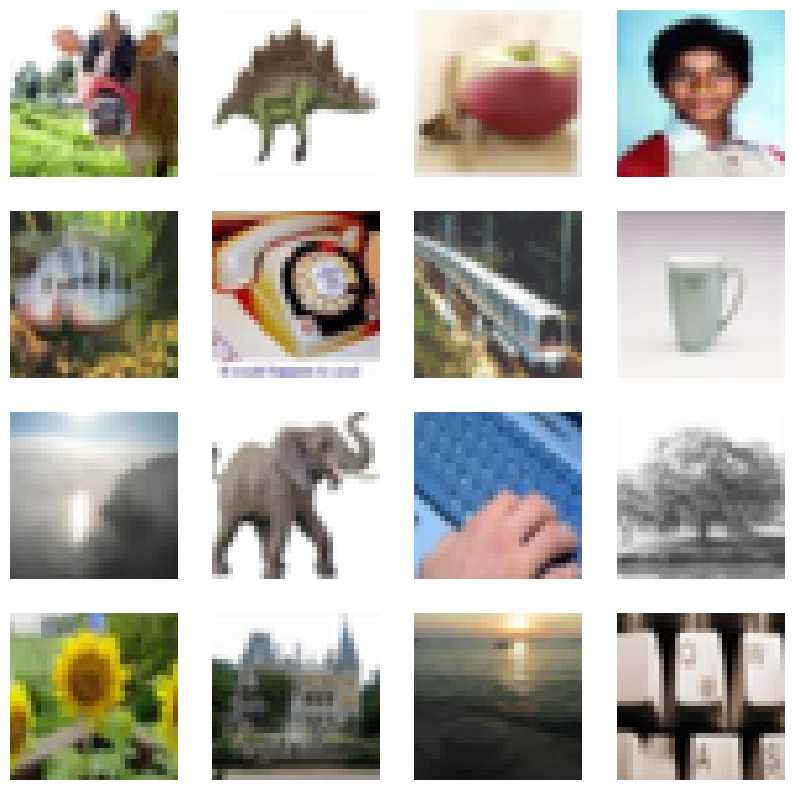

In [8]:
#plotting some images
plt.figure(figsize=(10, 10))

for i in range (4*4):
  plt.subplot(4, 4, i+1)
  plt.imshow(X_train[i])
  plt.axis('off')

plt.show()

In [ ]:
#create model
model = Sequential()
# 128 and not only 32 filters because there are 100 classes. 32 filters gave bad results.
model.add(Conv2D(128, (3, 3), padding='same', input_shape=X_train.shape[1:]))
model.add(Activation('elu'))

model.add(Conv2D(128, (3, 3)))
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(256, (3, 3), padding='same'))
model.add(Activation('elu'))

model.add(Conv2D(256, (3, 3)))
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Conv2D(512, (3, 3), padding='same'))
model.add(Activation('elu'))

model.add(Conv2D(512, (3, 3)))
model.add(Activation('elu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.25))

model.add(Flatten())
model.add(Dense(1024))
model.add(Activation('elu'))

In [ ]:
model.add(Dropout(0.5))
model.add(Dense(nb_classes))
model.add(Activation('softmax'))

model.summary()

C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 128)         │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 30, 30, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 30, 30, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 15, 15, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 15, 15, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 15, 15, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 13, 13, 256)         │         590,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 13, 13, 256)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 6, 6, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 6, 6, 512)           │       1,180,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 6, 6, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 512)           │       2,359,808 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_5 (Activation)            │ (None, 4, 4, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 2, 2, 512)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 1024)                │       2,098,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_6 (Activation)            │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼──────────────

 Total params: 6,777,060 (25.85 MB)

 Trainable params: 6,777,060 (25.85 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
from tensorflow.keras.optimizers.schedules import ExponentialDecay

lr_schedule = ExponentialDecay(
    initial_learning_rate=0.0001, decay_steps=100000, decay_rate=0.96, staircase=True
)

model.compile(
    loss="categorical_crossentropy",
    optimizer=Adam(learning_rate=lr_schedule),
    metrics=["accuracy"]
)

In [16]:
datagen = ImageDataGenerator(
            featurewise_center=False,  # set input mean to 0 over the dataset
            samplewise_center=False,  # set each sample mean to 0
            featurewise_std_normalization=False,  # divide inputs by std of the dataset
            samplewise_std_normalization=False,  # divide each input by its std
            zca_whitening=False,  # apply ZCA whitening
            rotation_range=0,  # randomly rotate images in the range (degrees, 0 to 180)
            width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
            height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
            horizontal_flip=True,  # randomly flip images
            vertical_flip=False)  # randomly flip images

datagen.fit(X_train)

In [18]:
early_stop = EarlyStopping(monitor='val_loss', mode='min', verbose=1, patience=8, restore_best_weights = True)

# Fit data to model
history = model.fit(datagen.flow(X_train, y_train, batch_size=50), 
                   steps_per_epoch=X_train.shape[0] // 50,
                   epochs=600,
                   validation_data=(X_test, y_test),
                   verbose=1,
                   callbacks=[early_stop])

Epoch 1/600


C:\Users\orlak\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1000/1000 ━━━━━━━━━━━━━━━━━━━━ 822s 820ms/step - accuracy: 0.0678 - loss: 4.1878 - val_accuracy: 0.2180 - val_loss: 3.3068
Epoch 2/600
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 823s 823ms/step - accuracy: 0.1846 - loss: 3.4238 - val_accuracy: 0.2931 - val_loss: 2.8940
Epoch 3/600
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 826s 826ms/step - accuracy: 0.2518 - loss: 3.0707 - val_accuracy: 0.3514 - val_loss: 2.6310
Epoch 4/600
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 869s 869ms/step - accuracy: 0.2940 - loss: 2.8615 - val_accuracy: 0.3648 - val_loss: 2.5220
Epoch 5/600
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 865s 865ms/step - accuracy: 0.3246 - loss: 2.7206 - val_accuracy: 0.4008 - val_loss: 2.3671
Epoch 6/600
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 851s 852ms/step - accuracy: 0.3475 - loss: 2.5946 - val_accuracy: 0.4010 - val_loss: 2.3541
Epoch 7/600
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1014s 1s/step - accuracy: 0.3718 - loss: 2.4845 - val_accuracy: 0.4257 - val_loss: 2.1975
Epoch 8/600
1000/1000 ━━━━━━━━━━━━━━━━━━━━ 1495s 1s/step - accuracy: 

Test loss: 1.3112157583236694 / Test accuracy: 0.6481999754905701


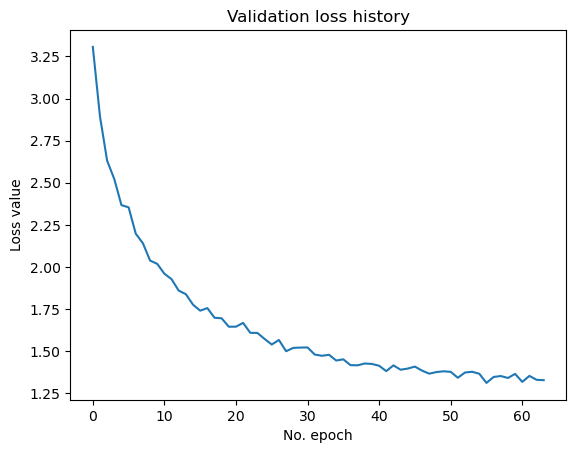

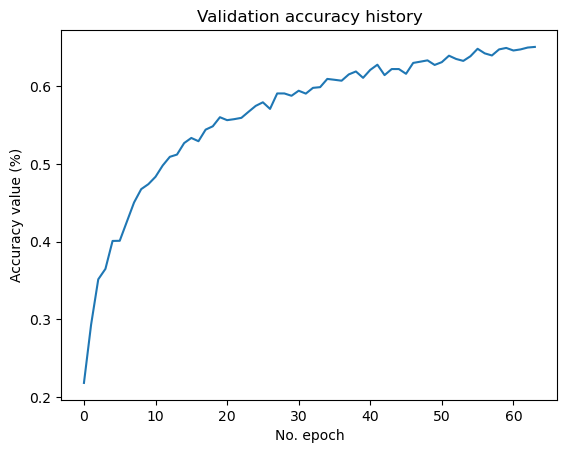

In [28]:
# Generate generalization metrics
score = model.evaluate(X_test, y_test, verbose=0)
print(f'Test loss: {score[0]} / Test accuracy: {score[1]}')

# Visualize history
# Plot history: Loss
plt.plot(history.history['val_loss'])
plt.title('Validation loss history')
plt.ylabel('Loss value')
plt.xlabel('No. epoch')
plt.show()

# Plot history: Accuracy
plt.plot(history.history['val_accuracy'])
plt.title('Validation accuracy history')
plt.ylabel('Accuracy value (%)')
plt.xlabel('No. epoch')
plt.show()

In [29]:
evaluation = model.evaluate(datagen.flow(X_test, y_test, batch_size=50),
                                      steps=X_test.shape[0] // 50)

print('Model Accuracy = %.2f' % (evaluation[1]))

200/200 ━━━━━━━━━━━━━━━━━━━━ 49s 245ms/step - accuracy: 0.6271 - loss: 1.4057
Model Accuracy = 0.63


Pierrevignoles (2021) Classification with CNN on CIFAR-100. https://www.kaggle.com/code/pierrevignoles/classification-with-cnn-on-cifar-100.

This Notebook has been released under the Apache 2.0 open source license.

This code was originally run with large amount of GPU 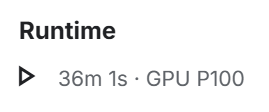, it has taken more than one day to complete 45 epochs on this machine. The original notebook had early stopping kick in after epoch 61 with accuracy 0.7124
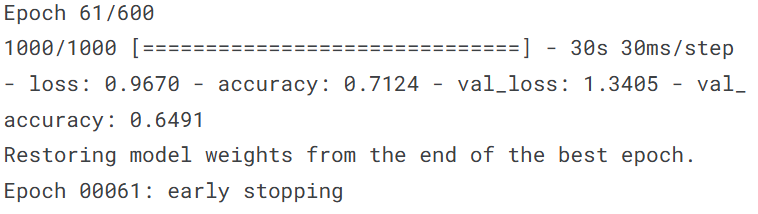